# Cloud optical depth, effective radius and LWP at the Scripps Pier: three instruments, three sets of assumptions

**EPCAPE, ARM Mobile Facility 1, Scripps Pier (M1), Feb 2023 – Feb 2024**

This notebook compares estimates of the same cloud properties from three ARM products. Each product uses a different instrument, field of view, sampling scheme and retrieval assumption. The goal is to show how those differences change what you would conclude about the clouds. None of these products is ground truth, so every result here is a **comparison**, not a validation.

| | **MFRSRCLDOD** (`epcmfrsrcldod1minM1.c1`) | **SPHOTCOD** (`epcsphotcod2chiuM1.c1`) | **MWRLOS** (`epcmwrlosM1.b1`) |
|---|---|---|---|
| Instrument | Multifilter rotating shadowband radiometer | Cimel sunphotometer, cloud mode | 2-channel microwave radiometer |
| Measurement | Total (hemispheric) transmittance, 415 nm | Zenith radiance, 440 / 870 / 1640 nm | Sky brightness temperature, 23.8 / 31.4 GHz |
| Field of view | Whole sky dome (diffuse) | 1.2° (≈10 m at 500 m cloud base) | 4.5–5.9° (≈50 m at 500 m) |
| Sampling | 20 s, daytime | One retrieval per 5–15 min, daytime, **only when cloud blocks the sun** | Seconds, day and night |
| τ | Plane-parallel inversion of diffuse transmittance (Min & Harrison 1996) | DISORT look-up table, solved jointly with r_e (Chiu et al. 2012) | — |
| r_e | From τ **and MWR LWP**: r_e = 3 LWP / (2 ρ_w τ); **8 µm assumed** if no MWR LWP ≥ 20 g m⁻² | From 1640 nm liquid absorption | — |
| LWP | MWR LWP, or (2/3) ρ_w τ × 8 µm | (2/3) ρ_w τ r_e | Statistical retrieval from the two channels |
| Surface albedo | 0.036 at 415 nm (fixed) | MODIS 500 m white-sky albedo, 16-day | — |
| Validity | Overcast, liquid, τ > ~7 | Sun obscured; uncertainty from 40 perturbed retrievals | No rain or wet window; ±30 g m⁻² retrieval RMS |
| Reference | DOE/SC-ARM-TR-047 (Turner et al. 2021) | DOE/SC-ARM-TR-317 (Ma et al. 2025) | DOE/SC-ARM-TR-016 (Morris 2019) |

**Independence matters.** When MFRSRCLDOD retrieves r_e, the LWP comes from an MWR retrieval (at EPCAPE mostly MWRRET, `mwrret1liljclou.c2`). So MFRSR r_e and LWP are *not* independent of the microwave radiometer. The independent comparisons are:
- τ: MFRSR vs SPHOT
- r_e: MFRSR vs SPHOT
- LWP: SPHOT vs MWR, and MFRSR-with-assumed-r_e vs MWR

Section 8 checks which MWR product the VAP actually used at EPCAPE.

Physics used in the comparison code, with sources in the module docstrings:
- Vertically uniform cloud (Stephens 1978): LWP = (2/3) ρ_w τ r_e. With ρ_w = 10⁶ g m⁻³ and r_e in µm, LWP [g m⁻²] = (2/3) τ r_e[µm].
- Adiabatic cloud (Wood & Hartmann 2006; Szczodrak et al. 2001): LWP = (5/9) ρ_w τ r_e,top. For the same τ and LWP, this implies a cloud-top radius 1.2× the vertically uniform r_e.

## How this notebook finds the data

This notebook never reads daily ARM files directly. `EPCAPE.analysis_tools.products.load_product` reads one combined file per product from `<data folder>/processed/`. If that file is missing, it builds it once from the daily files, wherever `config.yaml` says they live on this machine:

* **Laptop:** run the scripted, resumable downloads first (ARM Live token required). Each one keeps a `manifest.json`, so the dataset can be rebuilt.
  ```bash
  python download_data/download_arm.py cod_mfrsr_M1
  python download_data/download_arm.py cod_sphot_M1
  python download_data/download_arm.py lwp_mwr_M1
  ```
* **ARM JupyterHub / Cumulus:** `export EPCAPE_MACHINE=arm_jupyterhub`. The files are read in place from `/data/archive/epc/`, and nothing is downloaded.

To rebuild a combined file after downloading more days, pass `rebuild=True` in the load cell.

In [1]:
# --- Setup: make the repository importable from this sub-folder -------------
import sys
from pathlib import Path

def find_repo_root(start: Path = Path.cwd()) -> Path:
    # Walk up until the folder holding config.yaml (the EPCAPE repository root).
    for p in [start, *start.parents]:
        if (p / "config.yaml").is_file() and (p / "__init__.py").is_file():
            return p
    raise FileNotFoundError("Could not find the EPCAPE repository root (config.yaml) above " + str(start))

REPO = find_repo_root()
# EPCAPE/ is itself the package: its parent goes on sys.path for `import EPCAPE`,
# and EPCAPE/ itself for the instruments/ and comparisons/ sub-packages.
for _p in (REPO.parent, REPO):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import display

from EPCAPE.analysis_tools import filters, qc
from EPCAPE.download_data.config import active_machine
from EPCAPE.analysis_tools.derived import git_revision, save_derived
from EPCAPE.plotting import COLORS, use_style, savefig
from EPCAPE.analysis_tools.products import processed_path, source_file_attrs
from EPCAPE.analysis_tools.stats import paired_stats

from EPCAPE.instruments.mfrsr import mfrsrcldod, plots as mfrsr_plots
from EPCAPE.instruments.sunphotometer import sphotcod, plots as sphot_plots
from EPCAPE.instruments.mwr import mwrlos, plots as mwr_plots
from EPCAPE.comparisons.cloud_optical_properties import collocate, plots

use_style()
pd.set_option("display.width", 160, "display.max_columns", 20, "display.precision", 3)
machine = active_machine()
print(f"repository : {REPO}  (git {git_revision()})")
print(f"machine    : {machine.name}")
print(f"data folder: {machine.data_root}")

repository : /Users/andrewbuggee/Documents/VS_CODE/Python-Research/EPCAPE  (git 4e5fcb2-dirty)
machine    : local
data folder: /Users/andrewbuggee/Documents/VS_CODE/Python-Research/EPCAPE/data


## Settings

Every threshold lives here, and all of them are written into the attributes of the saved comparison file. Defaults:
* **MFRSR:** the selection in TR-047 §5 (cloud fraction > 0.9, τ > 7, IR sky T > 268 K, cloud base < 4 km, r_e ≠ 8.00 µm).
* **MWR:** TR-016 (QC bits, both Tb < 100 K, LWP < 1000 g m⁻², zenith pointing). The wet-window heater flag is *not* used: at EPCAPE it is on 39% of the time, mostly through marine-layer nights, and the handbook says its cycling does not affect LWP. Use `mwrlos.Criteria(reject_wet_window=True)` for the strict screen.
* **Missing inputs:** a test whose input variable is missing or entirely NaN is reported as *skipped* in the tables (e.g. MFRSR `ir_temp`, which is empty for the whole campaign), instead of rejecting every sample.
* **SPHOT:** the retrieval from the **mean of the A and K gain** radiances (`SPHOT_GAIN = 2`), and `retrieval_flag` decoded as the bit-packed ARM QC field it is: a sample is kept only if it fails none of the tests assessed "Bad" (all seven in the EPCAPE files).
  * Tests 2–5 are the spectral-signature checks, which compare radiances at 440/675/870/1020 nm with the pattern expected for cloud.
  * Test 6 means fewer than 15 look-up-table solutions.
  * `SPHOT_IGNORE_FLAG_BITS` lets you leave tests out. Section 6b compares retrievals that fail *only* the spectral tests with the ones that pass everything.

`SZA_MAX_DEG` is my choice, not taken from either VAP document. Plane-parallel retrievals of both solar products degrade at low sun, so the same limit is applied to both. Set it to `None` to disable it.

In [2]:
START, END = None, None          # e.g. "2023-06-01", "2023-08-31"; None = whole campaign
REBUILD = False                  # True after downloading more days

WINDOW_HALF_WIDTH_MIN = 2.5      # MFRSR/MWR averaged over +/- this around each SPHOT retrieval
MIN_COVERAGE = 0.6               # fraction of MFRSR samples in the window that must pass its criteria
SZA_MAX_DEG = 75.0               # applied to MFRSR and SPHOT alike (not a VAP criterion; see above)
LWP_PAIR_HALF_WIDTH_MIN = 0.25   # MWR averaged over +/- 15 s around each 20 s MFRSR sample (section 8)
PLOT_SEED = 20231005             # seeds the random subset drawn in dense scatter plots (stats use all pairs)

SPHOT_GAIN = sphotcod.DEFAULT_GAIN     # 0 = A (aureole gain), 1 = K (sky gain), 2 = mean of A and K
SPHOT_IGNORE_FLAG_BITS = ()            # e.g. sphotcod.SPECTRAL_SIGNATURE_BITS to keep spectral-test failures

mfrsr_crit = mfrsrcldod.Criteria(sza_max_deg=SZA_MAX_DEG)
sphot_crit = sphotcod.Criteria(sza_max_deg=SZA_MAX_DEG, ignore_flag_bits=SPHOT_IGNORE_FLAG_BITS)
mwr_crit = mwrlos.Criteria()

SAVE_FIGURES = True
FIG_DIR = machine.processed_dir() / "derived" / "figures" / "compare_cloud_optical_properties"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def show(fig, name):
    # Display inline, then optionally save a copy (figures are derived products: kept outside git).
    display(fig)
    if SAVE_FIGURES:
        savefig(fig, FIG_DIR / f"{name}.png")
    else:
        plt.close(fig)

## 1. Load the three products

The first run combines the daily files, which takes about a minute per product. Later runs read the cached combined file.

In [3]:
mfrsr = mfrsrcldod.standardize(mfrsrcldod.load(START, END, rebuild=REBUILD))
sphot_raw = sphotcod.load(START, END, rebuild=REBUILD)            # all three gains
sphot = sphotcod.standardize(sphot_raw, gain=SPHOT_GAIN)
mwr = mwrlos.standardize(mwrlos.load(START, END, rebuild=REBUILD))

def describe(ds):
    t = ds["time"].values
    dt_s = np.median(np.diff(t).astype("timedelta64[ms]").astype(float)) / 1e3 if t.size > 1 else np.nan
    return {"samples": t.size, "first": str(t[0])[:16], "last": str(t[-1])[:16], "median step (s)": dt_s,
            "variables": ", ".join(v for v in ds.data_vars if not v.startswith("qc_"))}

display(pd.DataFrame({ds.attrs["instrument"]: describe(ds) for ds in (mfrsr, sphot, mwr)}).T)

,samples,first,last,median step (s),variables
MFRSR,1573528,2023-02-15T00:00,2024-02-14T22:59,20.0,"tau, tau_avg5min, r_e_um, r_e_avg5min_um, tau_..."
SPHOT,11883,2023-02-15T00:02,2024-02-13T15:42,300.0,"tau, r_e_um, lwp_gm2, tau_std, r_e_std_um, lwp..."
MWR,1251788,2023-02-15T00:00,2024-02-14T23:00,20.0,"lwp_gm2, pwv_cm, tb23_K, tb31_K, wet_window"


## 2. Check the flags this analysis depends on

These printouts check assumptions in the code against the real files:
- **SPHOT `retrieval_flag`:** each QC test, how often it fails, and how often it is the *only* failure.
- **SPHOT surface albedo:** the MODIS white-sky albedo the retrieval assumed at 858 nm. Open ocean is roughly 0.03–0.05 there; vegetated land is roughly 0.2–0.4.
- **`lwp_source`:** how the MFRSR VAP encodes "LWP from MWR".
- **QC tests:** what each product's QC field tests.
- **`input_datastreams`:** which datastreams the MFRSR VAP used. The MWR one decides whether MFRSR r_e is tied to `mwrlos` or to another MWR retrieval.

In [4]:
if "retrieval_flag" in sphot:
    print(f"SPHOT retrieval_flag tests (gain: {sphot.attrs['gain']}); percentages of all retrievals:")
    display(qc.bit_breakdown(sphot["retrieval_flag"]).round(1))
alb858 = sphotcod.albedo_at(sphot, 858.0)
if alb858 is not None:
    a = alb858.values[np.isfinite(alb858.values)]
    print(f"MODIS white-sky albedo assumed at 858 nm: median {np.median(a):.3f}, "
          f"5th-95th percentile {np.percentile(a, 5):.3f}-{np.percentile(a, 95):.3f} (N = {a.size} retrievals)")

if "lwp_source" in mfrsr:
    print("\nMFRSR lwp_source meanings:", qc.flag_meanings(mfrsr["lwp_source"]) or "not described in file")
print(f"MFRSR samples with r_e from MWR LWP (r_e != 8.00 um): "
      f"{100 * float(mfrsr['r_e_from_mwr'].sum()) / max(int(np.isfinite(mfrsr['r_e_um']).sum()), 1):.1f}% "
      "of finite r_e")

print()
for name, var in [("cod_mfrsr_M1", "optical_depth_instantaneous"), ("lwp_mwr_M1", "liq"),
                  ("cod_sphot_M1", "cloud_optical_depth")]:
    with xr.open_dataset(processed_path(name)) as raw:
        print(qc.describe_qc(raw, var))

attrs = source_file_attrs("cod_mfrsr_M1")
print("\nMFRSRCLDOD input_datastreams:", attrs.get("input_datastreams", "(attribute not present)"))
print("  read from:", attrs.get("_read_from", "(no daily file on this machine)"))

SPHOT retrieval_flag tests (gain: mean of A and K); percentages of all retrievals:


,bit,value,assessment,failing_pct,only_this_pct,description
0,1,1,Bad,0.0,0.0,abs((870-870k)/870) >0 .2 or abs((440-440k)/44...
1,2,2,Bad,2.1,1.1,(440 > 870) and (440-675 < 675-870): Radiance ...
2,3,4,Bad,11.7,10.1,(440 < 870) and (870-675 <= 1020-870): abs(NIR...
3,4,8,Bad,5.7,4.4,(440 < 870) and (870-675 <= 675-440): abs(NIR-...
4,5,16,Bad,59.9,55.0,(440 < 870) and (870-675 <= 675-440) and (870-...
5,6,32,Bad,15.6,1.9,Number of solutions < 15
6,7,64,Bad,11.8,0.0,Missing data
7,-,0,,NaN,13.8,passed every test


MODIS white-sky albedo assumed at 858 nm: median 0.177, 5th-95th percentile 0.038-0.244 (N = 11883 retrievals)

MFRSR lwp_source meanings: {0: 'no_source_available', 1: 'mwrret1liljclou.c1:phys_lwp', 2: 'none: lwp is derived from mfrsr.b1 using the formula (2/3) * default_re * optical_depth_instantaneous', 3: 'mwrret1liljclou.c1:stat2_lwp', 4: 'mwrret1liljclou.c2:phys_lwp', 5: 'mwrret1liljclou.c2:stat2_lwp', 6: 'mwrret2turn.c1:phys_lwp', 7: 'mwrret2turn.c1:stat_lwp', 8: 'mwrlos.b1:liq'}
MFRSR samples with r_e from MWR LWP (r_e != 8.00 um): 59.7% of finite r_e

qc_optical_depth_instantaneous: 1,573,528 samples, 0.0% QC value missing
  bit    1 [Bad          ]   0.0%  Value is less than the valid_min, data value set to missing_value in output file
  bit    2 [Bad          ]  58.0%  cosine_solar_zenith_angle < 0.2, no retrieval could be attempted, data value set to missing_value in output file
  bit    4 [Bad          ]  18.9%  total_transmittance_filter1 > 1 or < 0, no retrieval attempte

## 3. Filtering: what each product keeps

Each table lists the criteria in the order they are applied. `remaining_pct` is the percentage of *all* samples that survive up to and including that row. Large drops tell you where each product's conclusions are conditioned. For example, the MFRSR cloud-fraction test keeps only overcast scenes.

In [5]:
# Criteria (ordered dicts of named boolean masks) for each quantity
c_mfrsr_tau = mfrsrcldod.tau_criteria(mfrsr, mfrsr_crit)
c_mfrsr_re = mfrsrcldod.r_e_criteria(mfrsr, mfrsr_crit)
c_sphot_tau = sphotcod.tau_criteria(sphot, sphot_crit)
c_sphot_lwp = sphotcod.lwp_criteria(sphot, sphot_crit)
c_mwr = mwrlos.lwp_criteria(mwr, mwr_crit)

for crit, label in [(c_mfrsr_re, "MFRSR (tau, then r_e)"), (c_sphot_lwp, "SPHOT (tau, r_e, LWP)"),
                    (c_mwr, "MWR LWP")]:
    print(label); display(filters.funnel(crit)); print()

# Combined masks (True = valid) and masked fields (NaN where invalid)
ok_mfrsr_tau, ok_mfrsr_re = filters.combine(c_mfrsr_tau), filters.combine(c_mfrsr_re)
ok_sphot_tau, ok_sphot_lwp = filters.combine(c_sphot_tau), filters.combine(c_sphot_lwp)
ok_mwr = filters.combine(c_mwr)

MFRSR (tau, then r_e)


,criterion,remaining,remaining_pct,removed_here
0,finite tau,279515.0,17.764,1294013
1,QC (instantaneous tau),279515.0,17.764,0
2,tau > 7,216518.0,13.760,62997
3,cloud fraction > 0.9,208321.0,13.239,8197
4,IR sky T > 268 K (skipped: variable missing or...,NaN,NaN,0
5,cloud base < 4000 m,196804.0,12.507,11517
6,SZA < 75 deg,185773.0,11.806,11031
7,finite r_e > 0,185773.0,11.806,0
8,QC (instantaneous r_e),185773.0,11.806,0
9,r_e from MWR LWP (not 8.00 um default),146099.0,9.285,39674



SPHOT (tau, r_e, LWP)


,criterion,remaining,remaining_pct,removed_here
0,finite tau > 0,10478,88.176,1405
1,QC (tau),10478,88.176,0
2,retrieval_flag: no Bad test failed,1636,13.768,8842
3,SZA < 75 deg,969,8.155,667
4,finite r_e > 0,969,8.155,0
5,finite LWP,969,8.155,0



MWR LWP


,criterion,remaining,remaining_pct,removed_here
0,finite LWP,1.244e+06,99.341,8254
1,"QC (liq, minimum test ignored)",1.244e+06,99.340,14
2,"Tb23, Tb31 < 100 K",1.229e+06,98.178,14534
3,LWP < 1000 g m-2 (no rain / dew on window),1.222e+06,97.603,7198
4,zenith pointing (|elev - 90| <= 1 deg) (skippe...,NaN,NaN,0


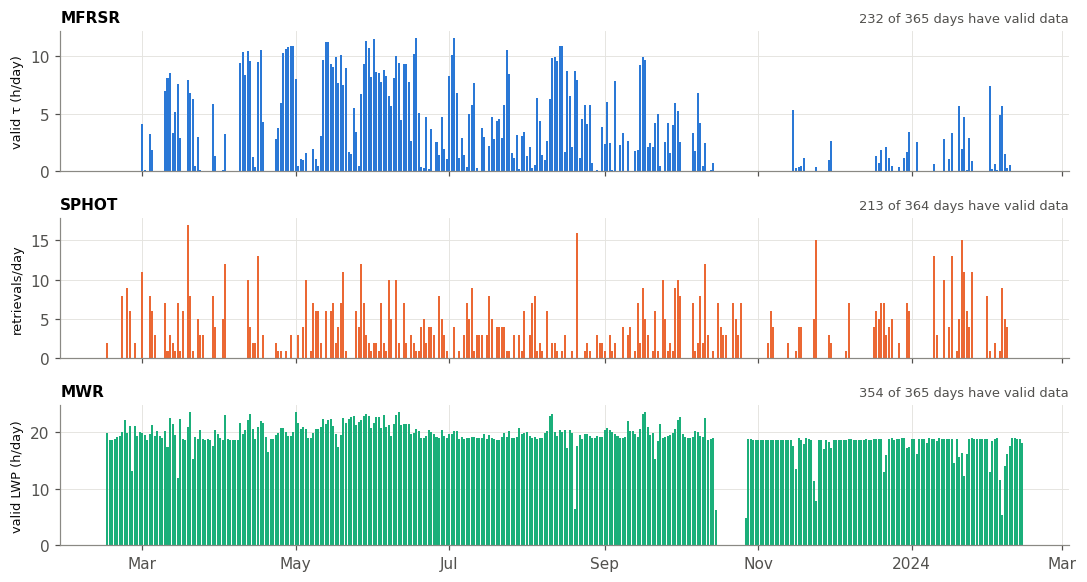

In [6]:
# Valid data per day. MFRSR and MWR are converted to hours of valid data; SPHOT
# stays a count of retrievals because each retrieval is a single sample.
def hours_per_day(mask, ds):
    step_s = np.median(np.diff(ds["time"].values).astype("timedelta64[ms]").astype(float)) / 1e3
    return filters.daily_counts(mask) * step_s / 3600.0

counts = {"MFRSR": hours_per_day(ok_mfrsr_tau, mfrsr),
          "SPHOT": filters.daily_counts(ok_sphot_tau),
          "MWR": hours_per_day(ok_mwr, mwr)}
fig = plots.plot_daily_coverage(counts, {"MFRSR": "valid τ (h/day)", "SPHOT": "retrievals/day",
                                         "MWR": "valid LWP (h/day)"})
show(fig, "01_daily_coverage")

## 4. Collocation on the sunphotometer's sample times

The sunphotometer gives one retrieval per cloud-mode cycle, so its sample times set the comparison. For each SPHOT retrieval, the MFRSR and MWR samples that passed their criteria are averaged over ± `WINDOW_HALF_WIDTH_MIN`. The window also yields:
* `*_coverage`: the fraction of the window's samples that passed the criteria. Low MFRSR coverage means the scene was broken or variable.
* `*_sd`: the within-window standard deviation. `mfrsr_tau_sd / mfrsr_tau` (the coefficient of variation) is used below as a proxy for cloud heterogeneity.

A τ pair counts as valid only when MFRSR coverage ≥ `MIN_COVERAGE`.

In [7]:
sources = {
    "mfrsr_tau": filters.apply(mfrsr["tau"], ok_mfrsr_tau),
    "mfrsr_r_e_um": filters.apply(mfrsr["r_e_um"], ok_mfrsr_re),
    "mwr_lwp_gm2": filters.apply(mwr["lwp_gm2"], ok_mwr),
}
if "cloud_fraction" in mfrsr:
    sources["mfrsr_cloud_fraction"] = mfrsr["cloud_fraction"]          # unmasked: describes the scene
target = {
    "sphot_tau": filters.apply(sphot["tau"], ok_sphot_tau),
    "sphot_r_e_um": filters.apply(sphot["r_e_um"], ok_sphot_lwp),
    "sphot_lwp_gm2": filters.apply(sphot["lwp_gm2"], ok_sphot_lwp),
}
for opt in ("tau_std", "r_e_std_um", "lwp_std_gm2", "sza_deg"):
    if opt in sphot:
        target[f"sphot_{opt}"] = sphot[opt]
if alb858 is not None:
    target["sphot_albedo_858nm"] = alb858

matched = collocate.match_to_times(target, sources, WINDOW_HALF_WIDTH_MIN)

# Pair validity
pair_tau = np.isfinite(matched["sphot_tau"]) & (matched["mfrsr_tau_coverage"] >= MIN_COVERAGE)
pair_re = pair_tau & np.isfinite(matched["sphot_r_e_um"]) & np.isfinite(matched["mfrsr_r_e_um"])
pair_lwp = np.isfinite(matched["sphot_lwp_gm2"]) & (matched["mwr_lwp_gm2_n"] > 0)
matched["pair_tau"], matched["pair_r_e"], matched["pair_lwp"] = pair_tau, pair_re, pair_lwp
matched["mfrsr_tau_cv"] = matched["mfrsr_tau_sd"] / matched["mfrsr_tau"]
matched["mfrsr_tau_cv"].attrs = {"long_name": "within-window coefficient of variation of MFRSR tau"}

n_sphot = int(np.isfinite(matched["sphot_tau"]).sum())
print(f"valid SPHOT retrievals            : {n_sphot}")
print(f"  ... with a valid MFRSR tau pair  : {int(pair_tau.sum())}"
      f"  ({100 * int(pair_tau.sum()) / max(n_sphot, 1):.0f}%)")
print(f"  ... with a valid r_e pair        : {int(pair_re.sum())}")
print(f"  ... with a valid MWR LWP pair    : {int(pair_lwp.sum())}")

valid SPHOT retrievals            : 969
  ... with a valid MFRSR tau pair  : 485  (50%)
  ... with a valid r_e pair        : 416
  ... with a valid MWR LWP pair    : 907


## 5. One day in detail

The day with the most valid τ pairs, shown in grey (rejected) and colour (valid). Two things to look for:
* **Scene changes:** how the three instruments respond when the scene changes, e.g. when the deck breaks up and the MFRSR cloud fraction drops.
* **Sampling:** where SPHOT retrievals exist but MFRSR samples are rejected, and the reverse.

Set `EXAMPLE_DAY` to inspect any other day. The per-instrument quicklooks below show each product's own variables.

example day: 2023-03-19 (17 tau pairs)


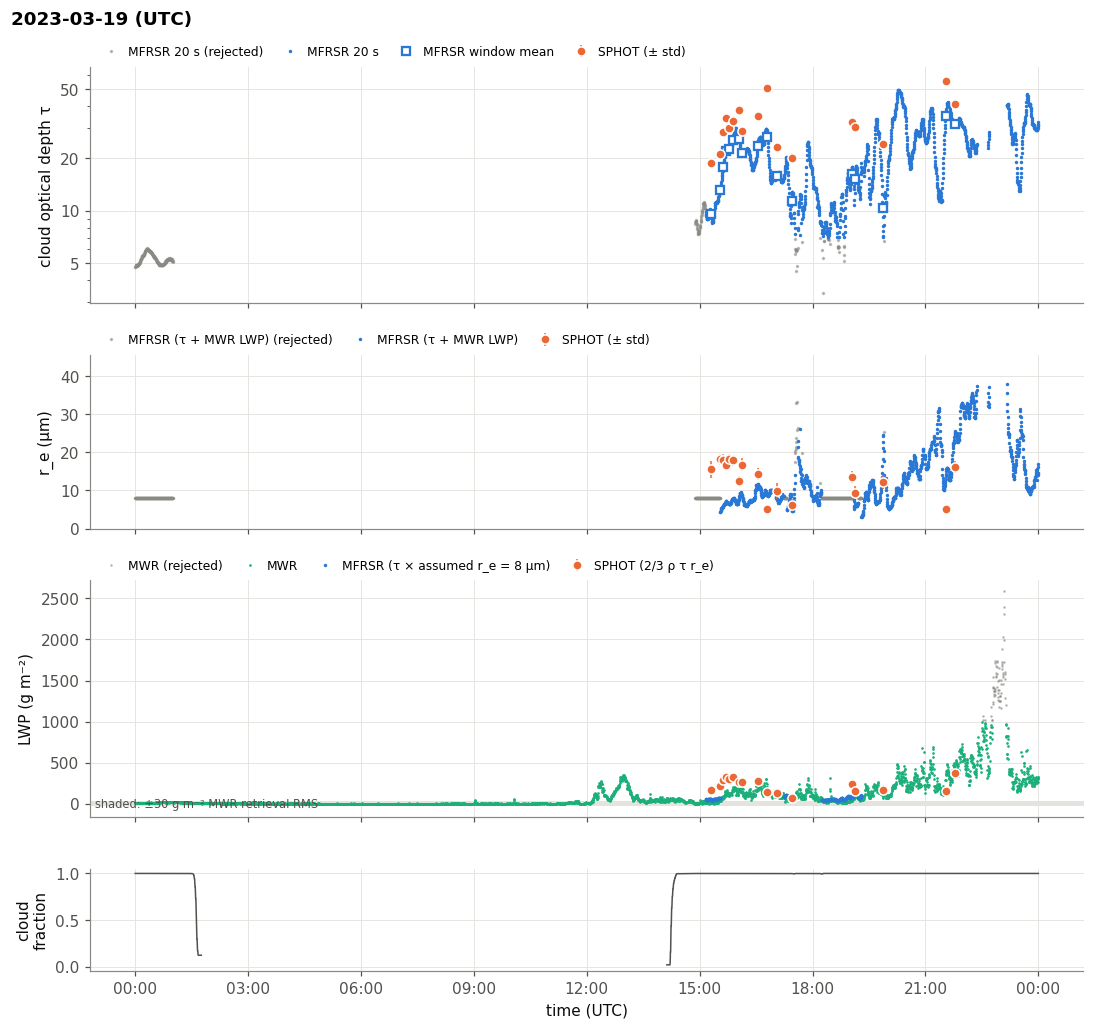

In [8]:
per_day = pd.Series(pair_tau.values, index=pd.DatetimeIndex(matched["time"].values)).resample("1D").sum()
EXAMPLE_DAY = str(per_day.idxmax().date()) if per_day.max() > 0 else str(pd.Timestamp(mfrsr["time"].values[0]).date())
print("example day:", EXAMPLE_DAY, f"({int(per_day.max())} tau pairs)")

fig = plots.plot_example_day(EXAMPLE_DAY, mfrsr, ok_mfrsr_tau, ok_mfrsr_re, sphot, ok_sphot_lwp, mwr, ok_mwr,
                             matched=matched.where(matched["pair_tau"]))
show(fig, f"02_example_day_{EXAMPLE_DAY}")

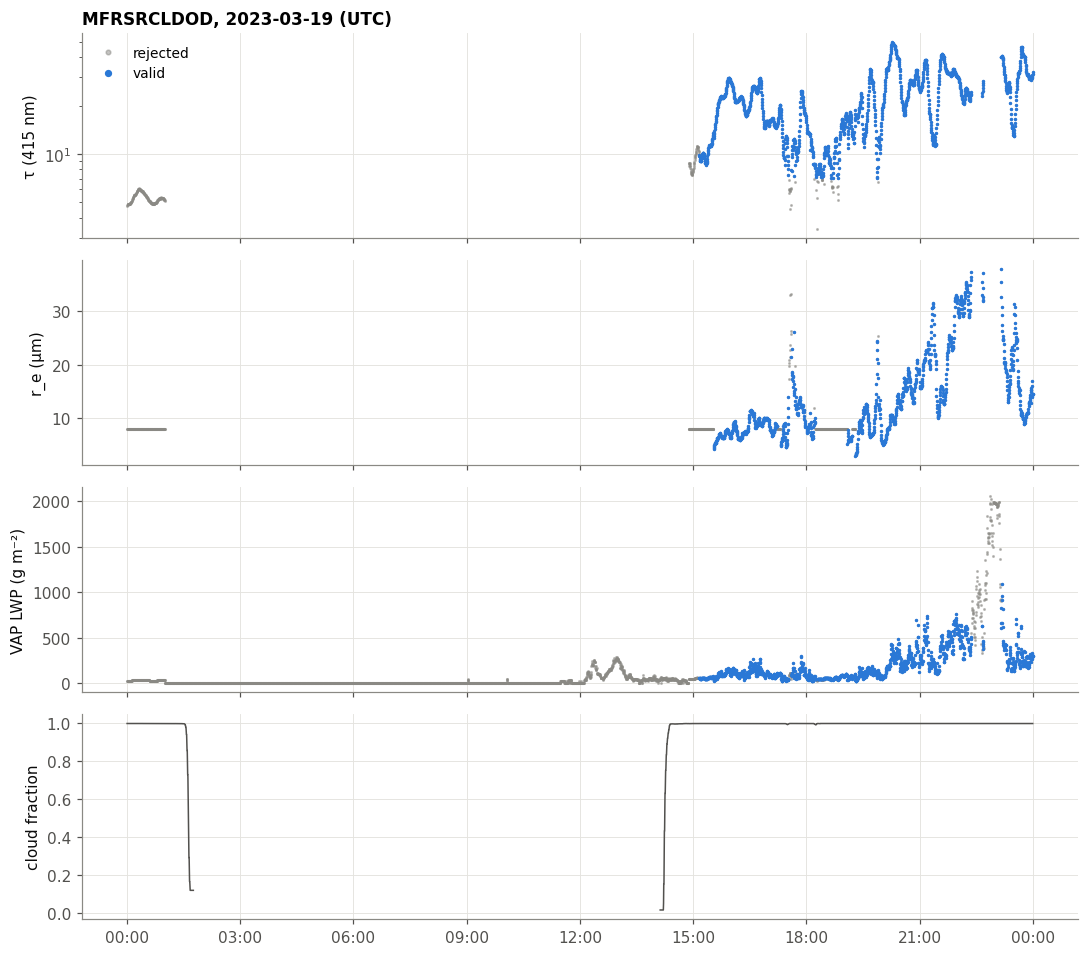

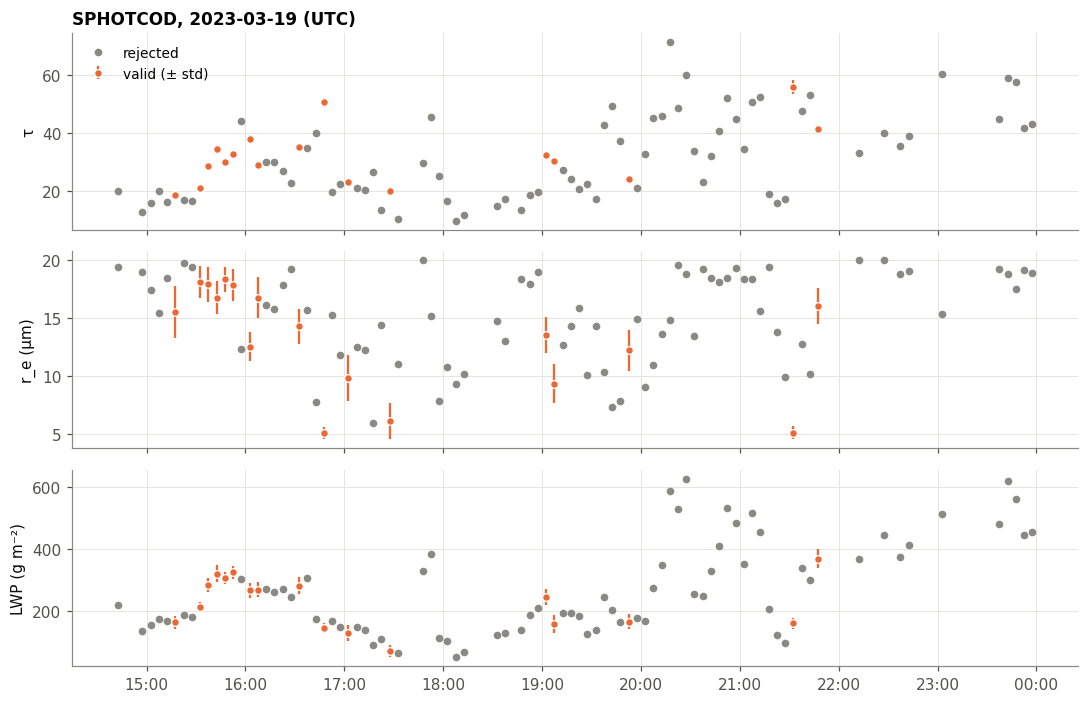

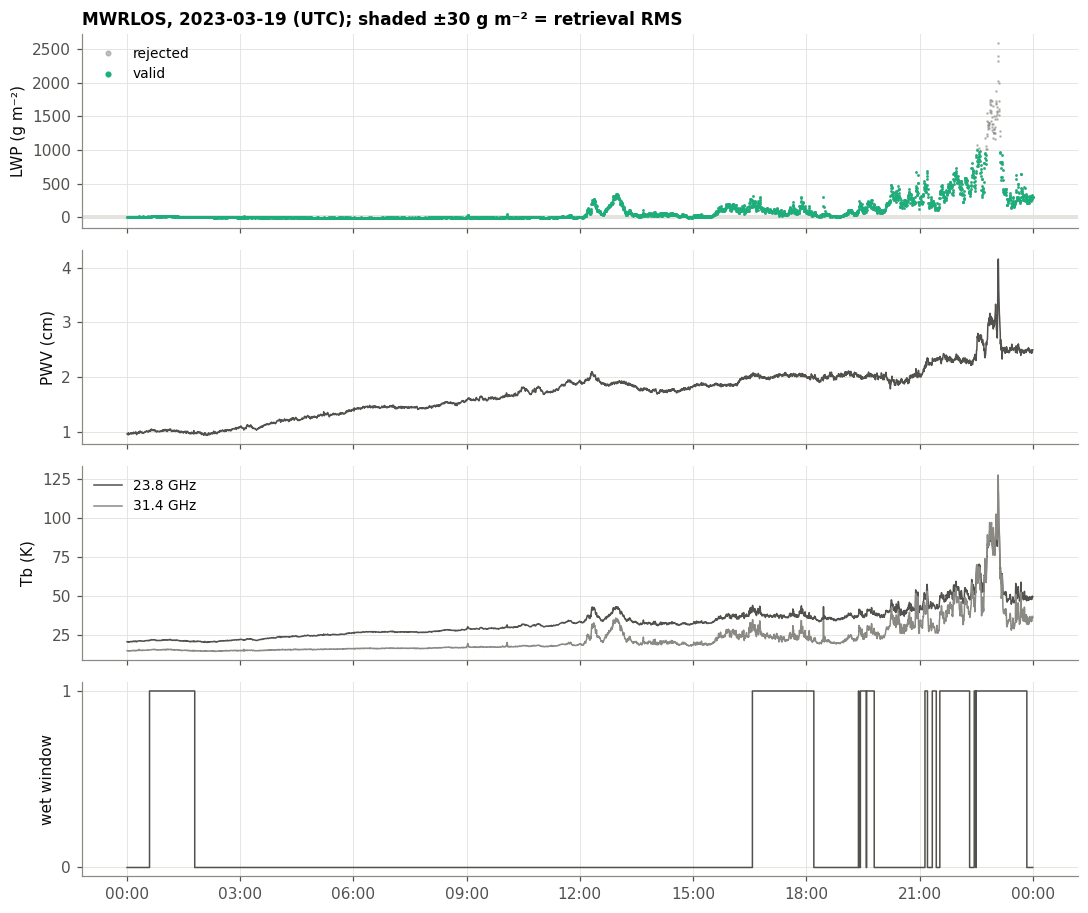

In [9]:
show(mfrsr_plots.quicklook_day(mfrsr, c_mfrsr_tau, c_mfrsr_re, EXAMPLE_DAY), f"03a_mfrsr_{EXAMPLE_DAY}")
show(sphot_plots.quicklook_day(sphot, c_sphot_lwp, EXAMPLE_DAY), f"03b_sphot_{EXAMPLE_DAY}")
show(mwr_plots.quicklook_day(mwr, c_mwr, EXAMPLE_DAY), f"03c_mwr_{EXAMPLE_DAY}")

## 5b. Sunphotometer: how much does the radiance gain matter?

The VAP runs the retrieval three times: on radiances measured with the aureole gain (A), with the sky gain (K), and on their mean, which this notebook uses. The same SPHOT criteria are applied to each gain.
* **Top figure:** the example day.
* **Second figure:** the whole campaign, as each single-gain retrieval's difference from the mean-gain retrieval, at times when all three pass.
* **Table:** median and 5th–95th percentile of those differences.

Differences much smaller than the SPHOT–MFRSR differences in section 6 mean the gain choice doesn't matter for the comparison.

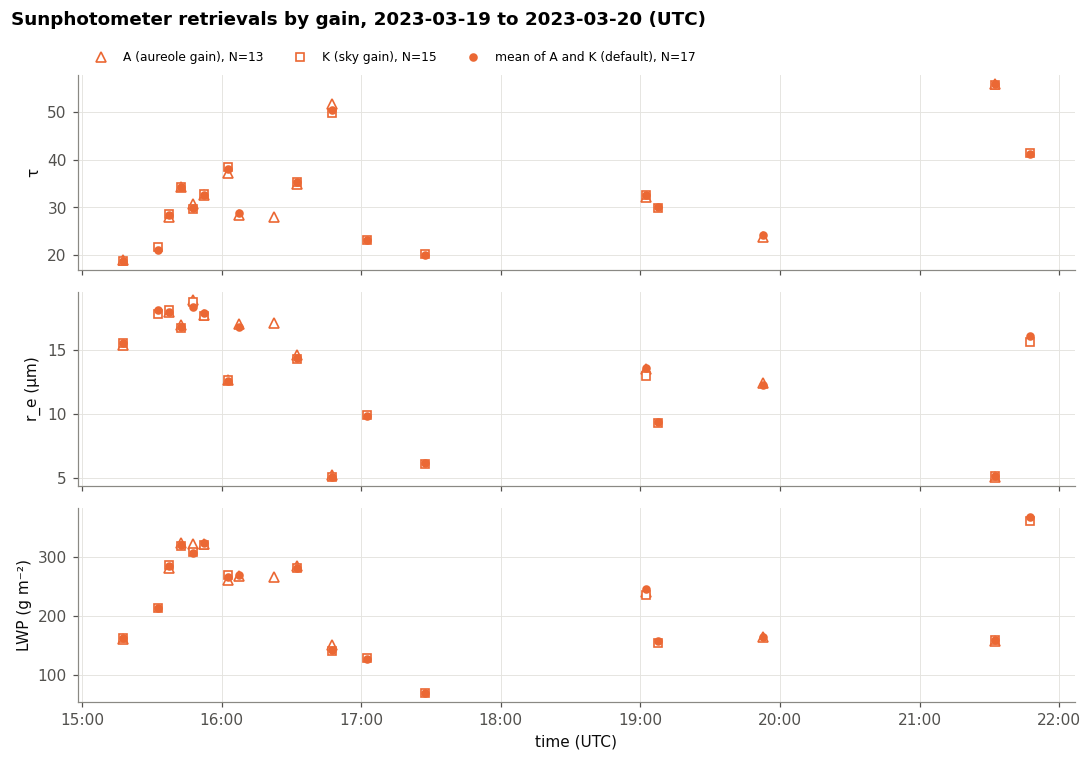

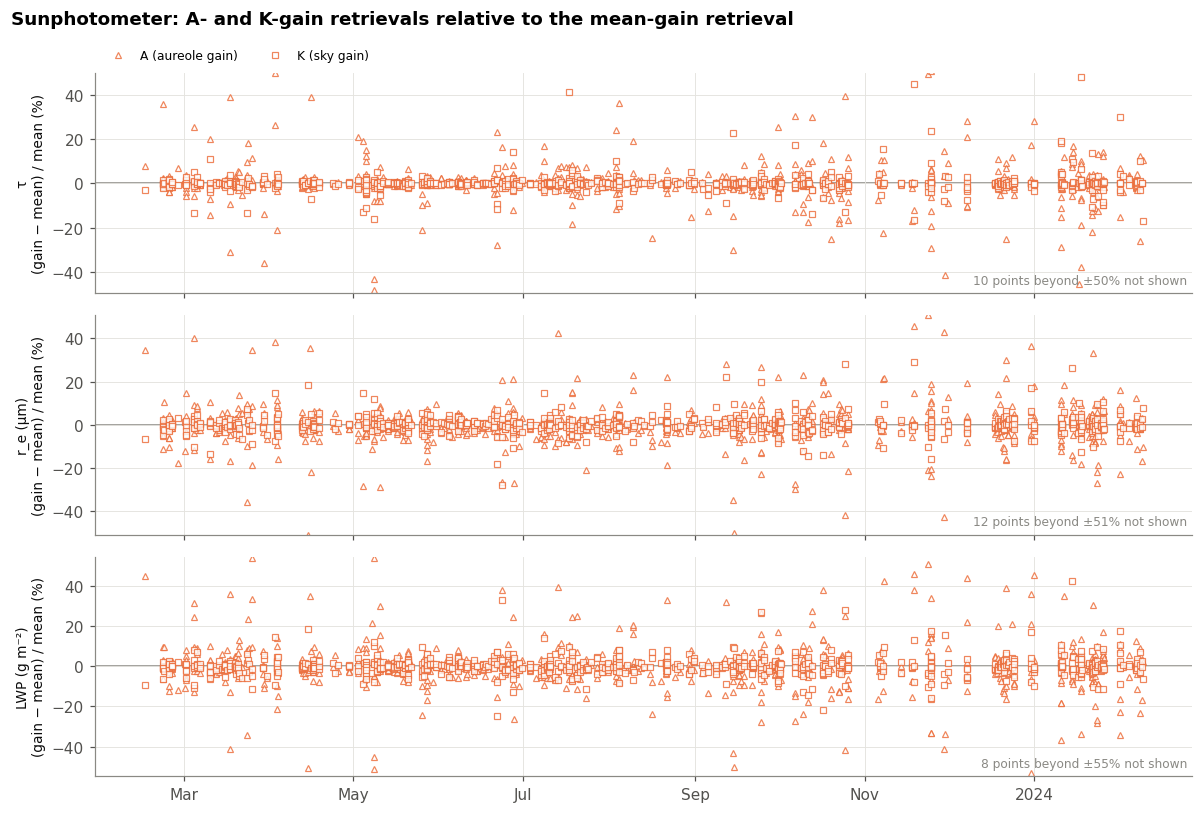

,quantity,gain,N,median_pct,p5_pct,p95_pct
0,tau,A (aureole gain),810,0.00,-12.58,12.22
1,tau,K (sky gain),810,0.00,-3.19,3.34
2,r_e_um,A (aureole gain),810,-0.29,-12.82,15.86
3,r_e_um,K (sky gain),810,0.07,-5.05,5.42
4,lwp_gm2,A (aureole gain),810,-0.42,-15.75,21.49
5,lwp_gm2,K (sky gain),810,0.14,-6.21,6.97


In [10]:
show(sphot_plots.gain_timeseries(sphot_raw, sphot_crit, EXAMPLE_DAY), f"03d_sphot_gains_{EXAMPLE_DAY}")
fig, gain_table = sphot_plots.gain_differences(sphot_raw, sphot_crit)
show(fig, "03e_sphot_gain_differences")
display(gain_table.round(2))

## 6. Optical depth: MFRSR (hemispheric, 415 nm) vs sunphotometer (zenith, 440/870/1640 nm)

The axes are logarithmic because τ spans more than a decade. Colour shows the within-window heterogeneity of the MFRSR τ. Points to keep in mind:
* **Regression line:** reduced-major-axis, because both axes carry retrieval error.
* **Previous result:** Sookdar et al. (2025) found r ≈ 0.81 between the two products at ENA and SGP, with the photometer biased high.
* **Interpretation:** a high bias that grows with heterogeneity points to field-of-view and 3-D effects. A bias that is steady across heterogeneity points more to calibration or albedo assumptions.

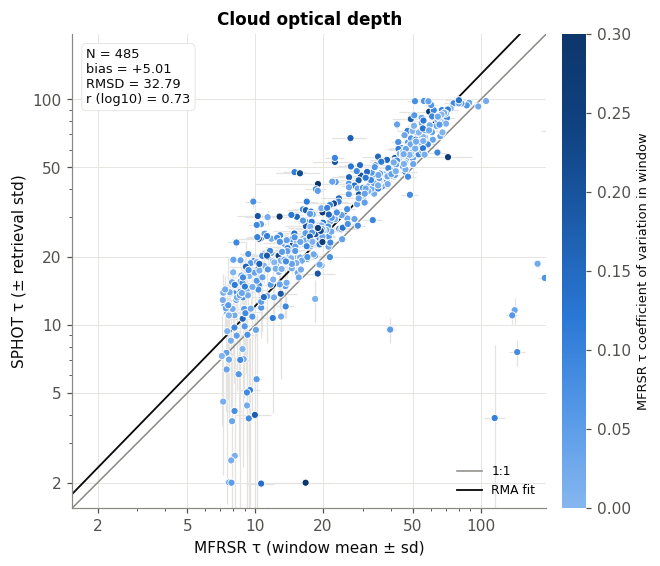

In [11]:
m = matched.where(matched["pair_tau"])
fig, ax = plt.subplots(figsize=(6.2, 5.6))
st_tau = plots.scatter_compare(
    ax, m["mfrsr_tau"], m["sphot_tau"], xerr=m["mfrsr_tau_sd"],
    yerr=m["sphot_tau_std"] if "sphot_tau_std" in m else None, log=True,
    xlabel="MFRSR τ (window mean ± sd)", ylabel="SPHOT τ (± retrieval std)",
    color_by=m["mfrsr_tau_cv"], color_label="MFRSR τ coefficient of variation in window", vmin=0, vmax=0.3)
ax.set_title("Cloud optical depth")
show(fig, "04_tau_scatter")

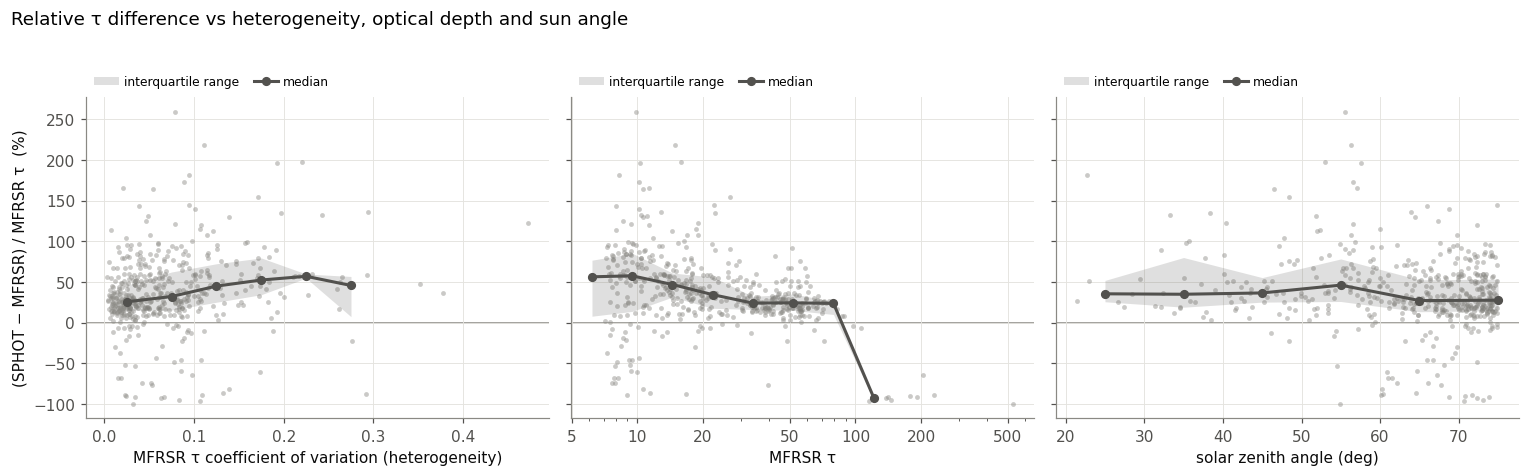

In [12]:
# What drives the disagreement? Relative difference against three candidate causes.
rel_diff_pct = 100 * (m["sphot_tau"] - m["mfrsr_tau"]) / m["mfrsr_tau"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
plots.binned_difference(axes[0], m["mfrsr_tau_cv"], rel_diff_pct, bins=np.linspace(0, 0.4, 9),
                        xlabel="MFRSR τ coefficient of variation (heterogeneity)",
                        ylabel="(SPHOT − MFRSR) / MFRSR τ  (%)")
plots.binned_difference(axes[1], m["mfrsr_tau"], rel_diff_pct, bins=np.geomspace(5, 150, 9), logx=True,
                        xlabel="MFRSR τ")
if "sphot_sza_deg" in m:
    plots.binned_difference(axes[2], m["sphot_sza_deg"], rel_diff_pct, bins=np.arange(10, 90, 10),
                            xlabel="solar zenith angle (deg)")
fig.suptitle("Relative τ difference vs heterogeneity, optical depth and sun angle", x=0.01, ha="left", y=1.02)
fig.tight_layout()
show(fig, "05_tau_difference_drivers")

## 6b. Sensitivity: should the spectral-signature tests be applied here?

Tests 2–5 of `retrieval_flag` (see section 2) remove most SPHOT retrievals at the pier. To see whether they remove *bad* retrievals, compare two groups against the independent instruments:
* **passes every test**, the default sample;
* **fails only the spectral tests** (2–5), which pass everything else.

If the second group agrees with the MFRSR τ and the MWR LWP about as well as the first, the tests are discarding good data at this site. If it agrees much worse, keep them.

The right panel plots the τ difference against the MODIS albedo the retrieval assumed at 858 nm. A trend there would implicate the surface assumption, whichever group the points belong to.

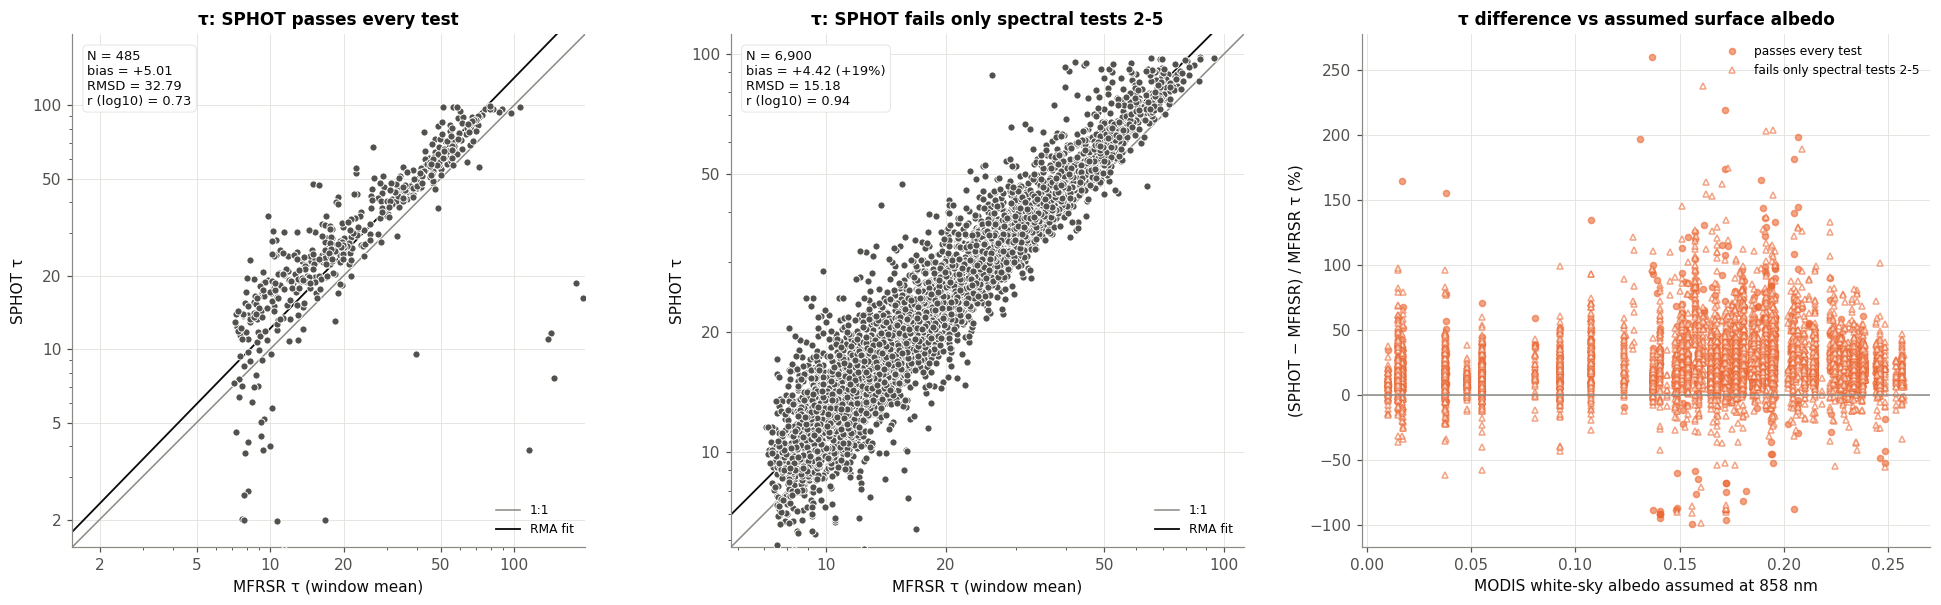

,n,mean_x,mean_y,bias,median_bias,rel_bias_pct,rmsd,r,rma_slope
"tau, passes every test",485,31.114,36.12,5.006,7.509,16.089,32.794,0.728,1.027
"LWP (g m-2), passes every test",907,127.844,126.729,-1.115,1.316,-0.872,104.694,0.68,0.982
"tau, fails only spectral tests 2-5",6900,23.33,27.747,4.417,3.985,18.934,15.176,0.937,1.0
"LWP (g m-2), fails only spectral tests 2-5",7700,128.51,163.128,34.618,29.249,26.938,72.758,0.848,1.181


In [13]:
crit_strict = sphotcod.Criteria(sza_max_deg=SZA_MAX_DEG)
crit_relaxed = sphotcod.Criteria(sza_max_deg=SZA_MAX_DEG, ignore_flag_bits=sphotcod.SPECTRAL_SIGNATURE_BITS)
ok_strict = filters.combine(sphotcod.lwp_criteria(sphot, crit_strict))
ok_relaxed = filters.combine(sphotcod.lwp_criteria(sphot, crit_relaxed))
spectral_only = ok_relaxed & ~ok_strict

target_rel = {"sphot_tau": filters.apply(sphot["tau"], ok_relaxed),
              "sphot_lwp_gm2": filters.apply(sphot["lwp_gm2"], ok_relaxed)}
if alb858 is not None:
    target_rel["sphot_albedo_858nm"] = alb858
sens = collocate.match_to_times(target_rel, {"mfrsr_tau": sources["mfrsr_tau"], "mwr_lwp_gm2": sources["mwr_lwp_gm2"]},
                                WINDOW_HALF_WIDTH_MIN)
tau_pair = np.isfinite(sens["sphot_tau"]) & (sens["mfrsr_tau_coverage"] >= MIN_COVERAGE)
lwp_pair = np.isfinite(sens["sphot_lwp_gm2"]) & (sens["mwr_lwp_gm2_n"] > 0)
groups = {"passes every test": ok_strict.values, "fails only spectral tests 2-5": spectral_only.values}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.6))
rows = {}
for ax, (label, g) in zip(axes[:2], groups.items()):
    sel = tau_pair.values & g
    rows[f"tau, {label}"] = plots.scatter_compare(
        ax, np.where(sel, sens["mfrsr_tau"], np.nan), np.where(sel, sens["sphot_tau"], np.nan), log=True,
        xlabel="MFRSR τ (window mean)", ylabel="SPHOT τ")
    ax.set_title(f"τ: SPHOT {label}")
    sel = lwp_pair.values & g
    rows[f"LWP (g m-2), {label}"] = paired_stats(np.where(sel, sens["mwr_lwp_gm2"], np.nan),
                                                 np.where(sel, sens["sphot_lwp_gm2"], np.nan))
if "sphot_albedo_858nm" in sens:
    rel = 100 * (sens["sphot_tau"] - sens["mfrsr_tau"]) / sens["mfrsr_tau"]
    for label, g, mk in [("passes every test", groups["passes every test"], "o"),
                         ("fails only spectral tests 2-5", groups["fails only spectral tests 2-5"], "^")]:
        sel = tau_pair.values & g
        axes[2].plot(sens["sphot_albedo_858nm"].values[sel], rel.values[sel], mk, ms=4, ls="none",
                     color=COLORS["SPHOT"], mfc="white" if mk == "^" else COLORS["SPHOT"], alpha=0.6, label=label)
    axes[2].axhline(0, color="#8a8984", lw=1)
    axes[2].set_xlabel("MODIS white-sky albedo assumed at 858 nm")
    axes[2].set_ylabel("(SPHOT − MFRSR) / MFRSR τ (%)")
    axes[2].set_title("τ difference vs assumed surface albedo")
    axes[2].legend(fontsize=8)
fig.tight_layout()
show(fig, "05b_spectral_test_sensitivity")
display(plots.stats_table(rows))

## 7. Effective radius: MFRSR (τ + MWR LWP) vs sunphotometer (1640 nm absorption)

These are physically different quantities that share a name:
* **MFRSR r_e** is the column-mean radius that makes τ consistent with an MWR LWP under the vertically uniform assumption. Its error is dominated by the MWR LWP error (TR-047 §4, Figure 3). An LWP error of ±20 g m⁻² at τ = 15 is ±2 µm in r_e.
* **SPHOT r_e** comes from absorption at 1640 nm in transmitted zenith radiance. Sookdar et al. (2025) report weak agreement with radar/radiometer r_e (r < 0.1, standard deviation ≈ 3 µm).

Expect scatter at the level of these uncertainties.

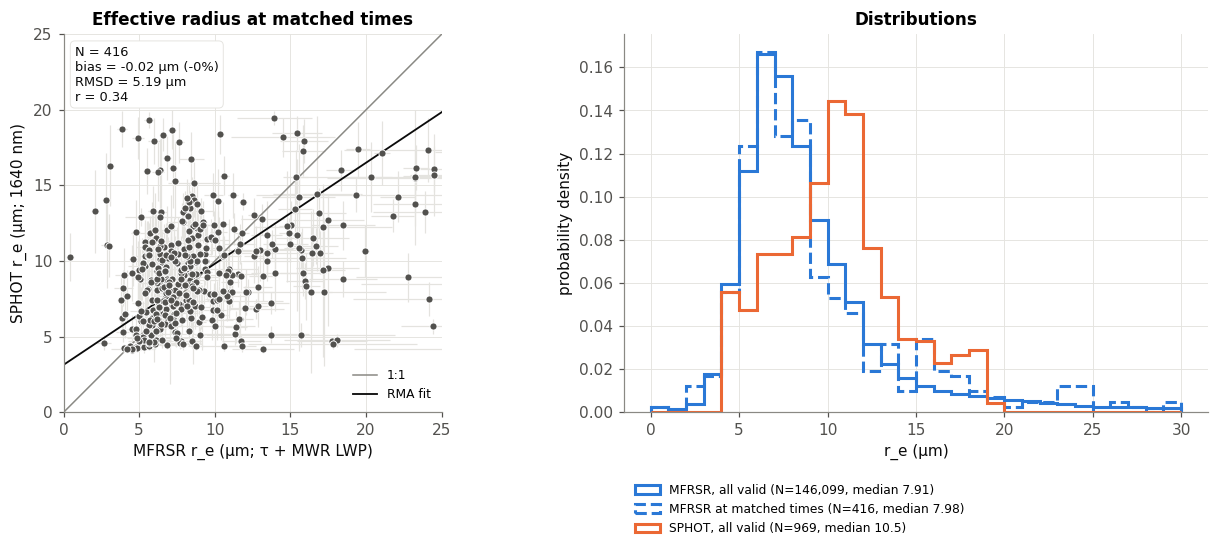

In [14]:
mr = matched.where(matched["pair_r_e"])
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
st_re = plots.scatter_compare(
    axes[0], mr["mfrsr_r_e_um"], mr["sphot_r_e_um"], xerr=mr["mfrsr_r_e_um_sd"],
    yerr=mr["sphot_r_e_std_um"] if "sphot_r_e_std_um" in mr else None, units="µm",
    xlabel="MFRSR r_e (µm; τ + MWR LWP)", ylabel="SPHOT r_e (µm; 1640 nm)", lims=(0, 25))
axes[0].set_title("Effective radius at matched times")
plots.plot_distributions(axes[1], [
    {"values": filters.apply(mfrsr["r_e_um"], ok_mfrsr_re).values, "label": "MFRSR, all valid", "instrument": "MFRSR"},
    {"values": mr["mfrsr_r_e_um"].values, "label": "MFRSR at matched times", "instrument": "MFRSR", "linestyle": "--"},
    {"values": filters.apply(sphot["r_e_um"], ok_sphot_lwp).values, "label": "SPHOT, all valid", "instrument": "SPHOT"},
], bins=np.arange(0, 30.5, 1.0), xlabel="r_e (µm)")
axes[1].set_title("Distributions")
fig.tight_layout()
show(fig, "06_r_e")

## 8. Liquid water path: three routes to one number

* **(a) SPHOT vs MWR at SPHOT times.** This is the independent comparison. SPHOT LWP = (2/3) ρ_w τ r_e, so it inherits the τ and r_e errors. Sookdar et al. (2025) report errors near 50 g m⁻² and r ≈ 0.7 against MWR retrievals.
* **(b) MFRSR with r_e = 8 µm assumed vs MWR.** These are the samples where the VAP had no usable MWR LWP. The question is how wrong a fixed 8 µm makes LWP at this site. Pairs are MFRSR 20 s samples against MWR means over ± `LWP_PAIR_HALF_WIDTH_MIN`.
* **(c) MFRSR VAP LWP when r_e came from an MWR vs MWRLOS.** At EPCAPE the VAP's `source_lwp` flag shows it mostly used **MWRRET** (`mwrret1liljclou.c2:phys_lwp`, a physical retrieval), not `mwrlos` (checked on 2023-02-15; section 2 prints the flag meanings). MWRRET and MWRLOS start from the **same radiometer's brightness temperatures** but use different retrievals. So this panel shows how much the choice of MWR retrieval alone changes LWP. That spread propagates directly into MFRSR r_e. Near-perfect agreement would instead mean the VAP used MWRLOS itself.

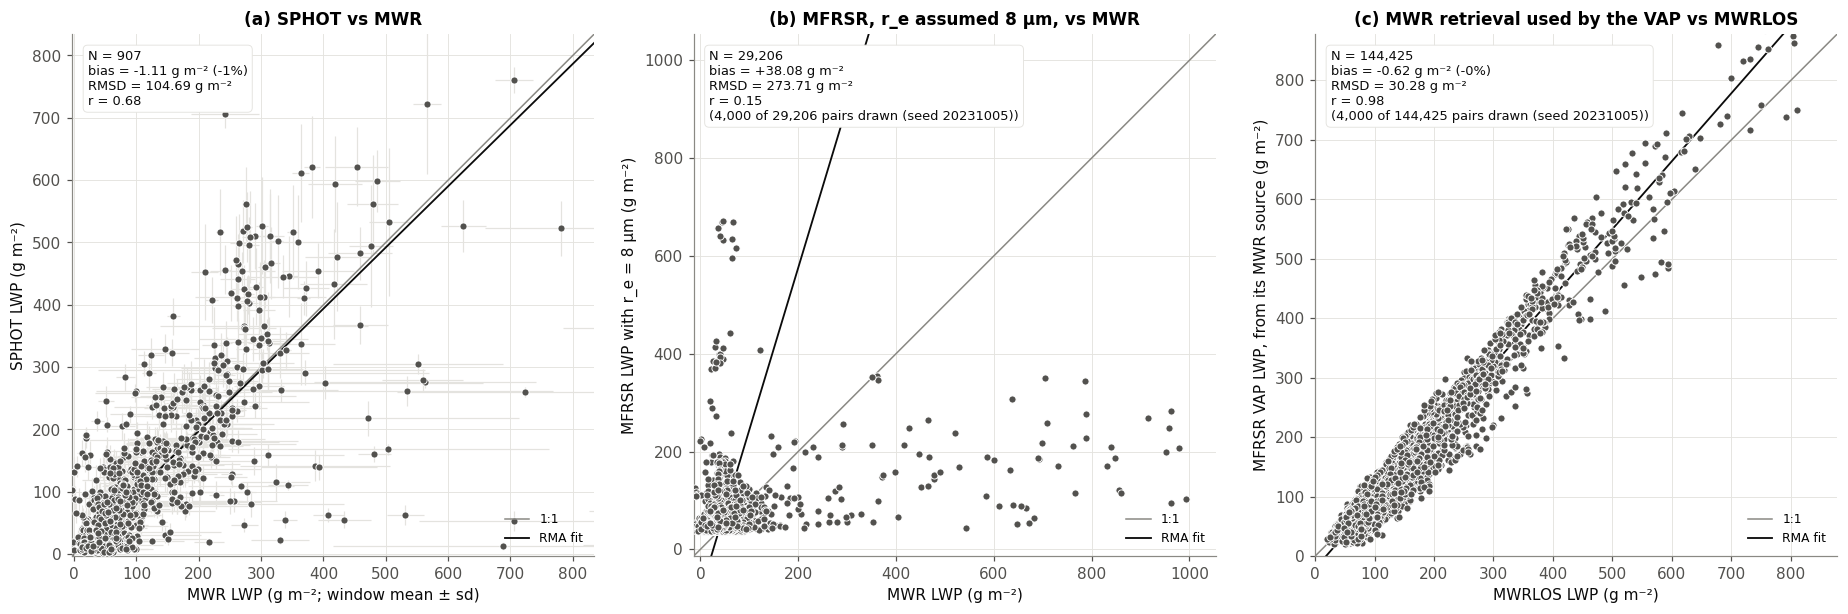

In [15]:
# MWR averaged around every MFRSR sample (for panels b and c)
mfrsr_lwp = mfrsr["lwp_gm2"] if "lwp_gm2" in mfrsr else xr.full_like(mfrsr["tau"], np.nan)
around_mfrsr = collocate.window_average({"mwr_lwp_gm2": filters.apply(mwr["lwp_gm2"], ok_mwr)},
                                        mfrsr["time"].values, LWP_PAIR_HALF_WIDTH_MIN)
mwr_at_mfrsr = around_mfrsr["mwr_lwp_gm2"].values
assumed = (ok_mfrsr_tau & ~mfrsr["r_e_from_mwr"]).values      # LWP = (2/3) tau * 8 um
from_mwr = (ok_mfrsr_tau & mfrsr["r_e_from_mwr"]).values       # LWP taken from an MWR

ml = matched.where(matched["pair_lwp"])
fig, axes = plt.subplots(1, 3, figsize=(17, 5.4))
st_lwp_sphot = plots.scatter_compare(
    axes[0], ml["mwr_lwp_gm2"], ml["sphot_lwp_gm2"], xerr=ml["mwr_lwp_gm2_sd"],
    yerr=ml["sphot_lwp_std_gm2"] if "sphot_lwp_std_gm2" in ml else None, units="g m⁻²",
    xlabel="MWR LWP (g m⁻²; window mean ± sd)", ylabel="SPHOT LWP (g m⁻²)")
axes[0].set_title("(a) SPHOT vs MWR")
st_lwp_assumed = plots.scatter_compare(
    axes[1], np.where(assumed, mwr_at_mfrsr, np.nan), np.where(assumed, mfrsr_lwp.values, np.nan),
    units="g m⁻²", xlabel="MWR LWP (g m⁻²)", ylabel="MFRSR LWP with r_e = 8 µm (g m⁻²)",
    max_points=4000, seed=PLOT_SEED)
axes[1].set_title("(b) MFRSR, r_e assumed 8 µm, vs MWR")
st_lwp_indep = plots.scatter_compare(
    axes[2], np.where(from_mwr, mwr_at_mfrsr, np.nan), np.where(from_mwr, mfrsr_lwp.values, np.nan),
    units="g m⁻²", xlabel="MWRLOS LWP (g m⁻²)", ylabel="MFRSR VAP LWP, from its MWR source (g m⁻²)",
    max_points=4000, seed=PLOT_SEED)
axes[2].set_title("(c) MWR retrieval used by the VAP vs MWRLOS")
fig.tight_layout()
show(fig, "07_lwp")

## 9. How much do the vertical-structure assumptions matter?

Both LWP products and the MFRSR r_e assume vertically uniform liquid water content, with the factor 2/3. Marine stratocumulus are often closer to adiabatic, where liquid water content increases linearly with height. With the adiabatic factor 5/9:
* SPHOT LWP would be 5/6 of the reported value, i.e. **17% lower**, if its r_e is read as a cloud-top radius.
* The MFRSR r_e implied by the same τ and LWP becomes a cloud-top radius **1.2×** larger.

Neither instrument retrieves a true cloud-top radius, so treat these as bounds on assumption sensitivity, not corrected values.

In [16]:
k = collocate.LWP_FACTOR_ADIABATIC / collocate.LWP_FACTOR_HOMOGENEOUS     # 5/6
rows = {
    "SPHOT LWP vs MWR, uniform (2/3)": paired_stats(ml["mwr_lwp_gm2"], ml["sphot_lwp_gm2"]),
    "SPHOT LWP vs MWR, adiabatic (5/9)": paired_stats(ml["mwr_lwp_gm2"], k * ml["sphot_lwp_gm2"]),
    "SPHOT r_e vs MFRSR r_e, uniform": paired_stats(mr["mfrsr_r_e_um"], mr["sphot_r_e_um"]),
    "SPHOT r_e vs MFRSR r_e,top, adiabatic (x1.2)": paired_stats(mr["mfrsr_r_e_um"] / k, mr["sphot_r_e_um"]),
}
display(plots.stats_table(rows))

,n,mean_x,mean_y,bias,median_bias,rel_bias_pct,rmsd,r,rma_slope
"SPHOT LWP vs MWR, uniform (2/3)",907,127.844,126.729,-1.115,1.316,-0.872,104.694,0.68,0.982
"SPHOT LWP vs MWR, adiabatic (5/9)",907,127.844,105.607,-22.236,-12.389,-17.393,100.993,0.68,0.818
"SPHOT r_e vs MFRSR r_e, uniform",416,9.533,9.509,-0.024,0.384,-0.252,5.187,0.336,0.668
"SPHOT r_e vs MFRSR r_e,top, adiabatic (x1.2)",416,11.44,9.509,-1.931,-1.035,-16.877,6.331,0.336,0.557


## 10. Sampling: does *when* each product sees the cloud change the climatology?

For τ, three curves separate two effects:
* **Sampling effect:** MFRSR at all valid times vs MFRSR at the matched SPHOT times. This is the same instrument restricted to the moments SPHOT also retrieved.
* **Retrieval / field-of-view effect:** MFRSR vs SPHOT at the same matched times.

For LWP, the MWR samples day and night, so comparing it at all times with the same MWR at SPHOT times shows how much a daytime, sun-blocked sample conditions the LWP climatology.

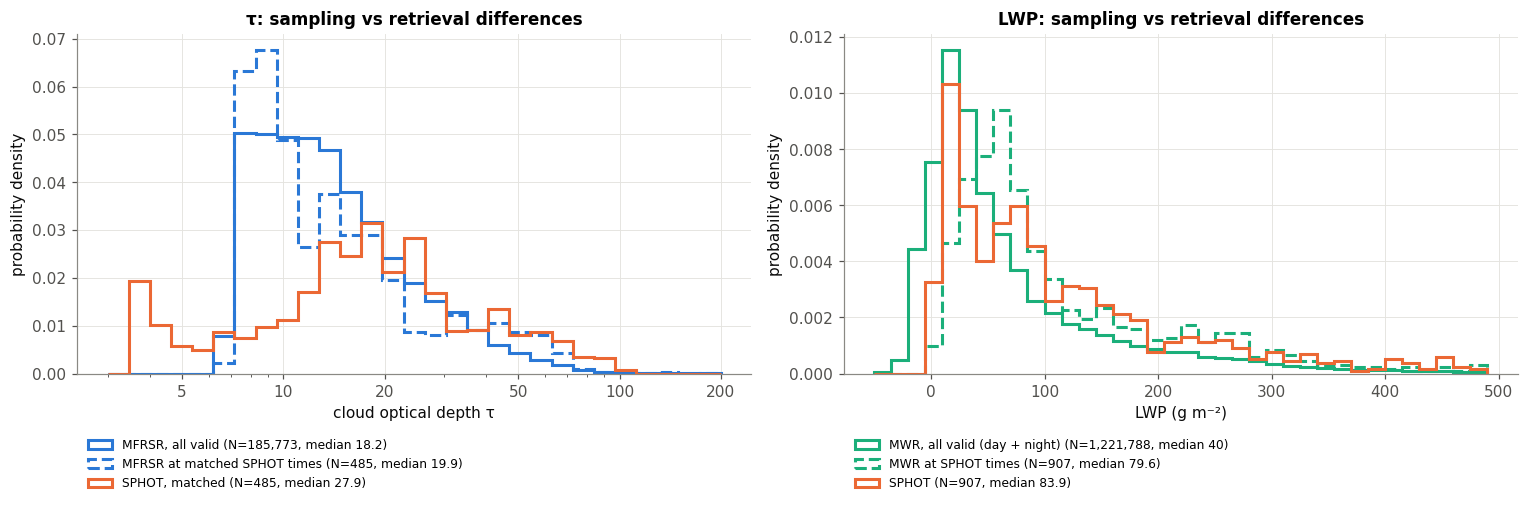

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
plots.plot_distributions(axes[0], [
    {"values": filters.apply(mfrsr["tau"], ok_mfrsr_tau).values, "label": "MFRSR, all valid", "instrument": "MFRSR"},
    {"values": m["mfrsr_tau"].values, "label": "MFRSR at matched SPHOT times", "instrument": "MFRSR", "linestyle": "--"},
    {"values": m["sphot_tau"].values, "label": "SPHOT, matched", "instrument": "SPHOT"},
], bins=np.geomspace(3, 200, 30), xlabel="cloud optical depth τ", log_x=True)
axes[0].set_title("τ: sampling vs retrieval differences")
plots.plot_distributions(axes[1], [
    {"values": filters.apply(mwr["lwp_gm2"], ok_mwr).values, "label": "MWR, all valid (day + night)", "instrument": "MWR"},
    {"values": ml["mwr_lwp_gm2"].values, "label": "MWR at SPHOT times", "instrument": "MWR", "linestyle": "--"},
    {"values": ml["sphot_lwp_gm2"].values, "label": "SPHOT", "instrument": "SPHOT"},
], bins=np.arange(-50, 501, 15), xlabel="LWP (g m⁻²)")
axes[1].set_title("LWP: sampling vs retrieval differences")
fig.tight_layout()
show(fig, "08_sampling")

## 11. Summary table

Bias = mean(y − x), with relative bias as a percentage of mean(x). RMSD is the root-mean-square difference. r is Pearson's correlation (on log₁₀ τ for the τ row). The RMA slope is the reduced-major-axis slope (log–log for τ).

In [18]:
summary = plots.stats_table({
    "tau: SPHOT (y) vs MFRSR (x)": st_tau,
    "r_e (um): SPHOT vs MFRSR": st_re,
    "LWP (g m-2): SPHOT vs MWR": st_lwp_sphot,
    "LWP (g m-2): MFRSR r_e=8um vs MWR": st_lwp_assumed,
    "LWP (g m-2): MFRSR from-MWR vs MWRLOS": st_lwp_indep,
})
display(summary)

,n,mean_x,mean_y,bias,median_bias,rel_bias_pct,rmsd,r,rma_slope
tau: SPHOT (y) vs MFRSR (x),485,31.114,36.12,5.006,7.509,16.089,32.794,0.728,1.027
r_e (um): SPHOT vs MFRSR,416,9.533,9.509,-0.024,0.384,-0.252,5.187,0.336,0.668
LWP (g m-2): SPHOT vs MWR,907,127.844,126.729,-1.115,1.316,-0.872,104.694,0.68,0.982
LWP (g m-2): MFRSR r_e=8um vs MWR,29206,54.18,92.262,38.083,17.618,70.289,273.714,0.145,3.315
LWP (g m-2): MFRSR from-MWR vs MWRLOS,144425,143.662,143.039,-0.623,-2.589,-0.434,30.283,0.978,1.142


## 12. Save the matched dataset for MATLAB / later analysis

The output goes to `<data folder>/processed/derived/`. Time is in POSIX seconds, missing values are NaN, and pair masks are stored as int8 0/1. Every threshold above and the git commit are written into the global attributes, so the file records how it was made. This is a derived product: back it up, but do not commit it to git.

```matlab
f = '<path printed below>';
t = datetime(ncread(f,'time'), 'ConvertFrom','posixtime', 'TimeZone','UTC');
ok = logical(ncread(f,'pair_tau'));
tau_sphot = ncread(f,'sphot_tau');  tau_mfrsr = ncread(f,'mfrsr_tau');
```

In [19]:
settings = {"start": START, "end": END, "window_half_width_min": WINDOW_HALF_WIDTH_MIN,
            "min_coverage": MIN_COVERAGE, "lwp_pair_half_width_min": LWP_PAIR_HALF_WIDTH_MIN,
            "plot_seed": PLOT_SEED}
settings.update({f"mfrsr_{k}": v for k, v in mfrsr_crit.as_dict().items()})
settings.update({f"sphot_{k}": v for k, v in sphot_crit.as_dict().items()})
settings.update({f"mwr_{k}": v for k, v in mwr_crit.as_dict().items()})
matched.attrs.update(
    title="EPCAPE M1: sunphotometer cloud retrievals matched with MFRSRCLDOD and MWRLOS",
    description=("One row per SPHOTCOD retrieval. mfrsr_* and mwr_* are means (and _sd, _n, _coverage) "
                 "of samples that passed each product's criteria within +/- window_half_width_min. "
                 "pair_* = 1 where the pair is valid for that comparison."),
    source_products="cod_sphot_M1 (epcsphotcod2chiuM1.c1), cod_mfrsr_M1 (epcmfrsrcldod1minM1.c1), "
                    "lwp_mwr_M1 (epcmwrlosM1.b1)",
)
out = save_derived(matched, "epcape_M1_sphot_mfrsr_mwr_matched", settings=settings)
print("wrote", out)

wrote /Users/andrewbuggee/Documents/VS_CODE/Python-Research/EPCAPE/data/processed/derived/epcape_M1_sphot_mfrsr_mwr_matched.nc


## Before drawing conclusions: what to check on the real data

1. **SPHOT spectral-signature tests (sections 2 and 6b).** They reject most retrievals at this site. Keep them, or ignore them, depending on what section 6b shows. The VAP authors at BNL (Ma, Giangrande), who also evaluated it at the ENA island site, are the right people to ask whether these tests are meant to apply over ocean.
2. **MWR source.** Read `source_lwp` (section 2) and panel 8(c). MFRSR r_e is tied to whichever MWR retrieval the VAP used (mostly MWRRET at EPCAPE), and so is its uncertainty.
3. **Surface albedo at a coastal pier.** MFRSR assumes 0.036 at 415 nm. SPHOT assumes the 500 m MODIS albedo, which at 858 nm is mostly land-like (~0.2, section 2) although the pier sits over the ocean. A τ bias that tracks that albedo (section 6b, right panel) points to the surface assumption, not the cloud.
4. **Drizzle.** Neither solar retrieval accounts for drizzle drops. Sookdar et al. (2025) find SPHOT LWP is unbiased only in non-drizzling cases. Adding KAZR or ceilometer drizzle screening is a natural next step; it would live under `instruments/kazr/` or `instruments/ceilometer/`.
5. **Window choices.** Repeat with `WINDOW_HALF_WIDTH_MIN` = 1 and 5 min, and `MIN_COVERAGE` = 0.4 and 0.8. Conclusions that depend on these choices are not robust.